In [2]:
# === SVR ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
import random
from pathlib import Path
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)


random_state = 42
seed_num = random_state
set_seed(seed_num)


C:\Users\w1304\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Function Section

In [ ]:
DATA_PATH = Path("SRB.xlsx")
desktop_data_path = Path(r"C:\Users\")
if not DATA_PATH.exists() and desktop_data_path.exists():
    DATA_PATH = desktop_data_path

EXPECTED_N_FEATURES = 25


def load_srb_dataset(data_path=DATA_PATH):
    df_all = pd.read_excel(data_path)
    df_process = df_all.dropna().reset_index(drop=True)

    feature_cols = list(df_process.columns[:-1])
    target_col = df_process.columns[-1]

    if len(feature_cols) != EXPECTED_N_FEATURES:
        raise ValueError(
            f"Expected {EXPECTED_N_FEATURES} input variables before the outcome column, "
            f"but found {len(feature_cols)}. Check that the last column is the SRB total score."
        )

    X = df_process.loc[:, feature_cols].to_numpy(dtype=float)
    y = df_process.loc[:, target_col].to_numpy(dtype=float)
    return df_process, feature_cols, target_col, X, y


def standardize_y(y_train, y_other=None):
    y_mean = y_train.mean()
    y_std = y_train.std()
    if y_std == 0:
        raise ValueError("The training-fold SRB total score has zero standard deviation.")

    y_train_nor = (y_train - y_mean) / y_std
    if y_other is None:
        return y_mean, y_std, y_train_nor

    y_other_nor = (y_other - y_mean) / y_std
    return y_mean, y_std, y_train_nor, y_other_nor


def inverse_standardize_y(y_pred_nor, y_mean, y_std):
    return y_pred_nor * y_std + y_mean


def build_svr_model():
    return SVR(kernel="rbf", C=1.0, epsilon=0.1, gamma="scale")


def evaluate_regress(y_true, y_pred, y_name=""):
    MAE = mean_absolute_error(y_true, y_pred)
    MSE = mean_squared_error(y_true, y_pred)
    RMSE = np.sqrt(MSE)
    R2 = r2_score(y_true, y_pred)

    print("*****************************************************")
    print(y_name + "MAE: ", str(MAE))
    print(y_name + "MSE: ", str(MSE))
    print(y_name + "RMSE: ", str(RMSE))
    print(y_name + "R2: ", str(R2))
    print("*****************************************************")

    return MAE, MSE, RMSE, R2



# Import data for training

In [4]:
# === SVR ===
df_process, feature_cols, target_col, X, y = load_srb_dataset(DATA_PATH)

random_state = 42
n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
cv_splits = list(kf.split(X))

name_label_list = ["SVR"]
evaluate_list = ["MAE", "MSE", "RMSE", "R2"]

cv_train_ev = []
cv_valid_ev = []
cv_models = []
cv_scalers = []
cv_y_stats = []

for fold, (train_index, valid_index) in enumerate(cv_splits, start=1):
    print(f"\n===== SVR Fold {fold}/{n_splits} =====")

    X_train, X_valid = X[train_index], X[valid_index]
    y_train, y_valid = y[train_index], y[valid_index]

    scaler = StandardScaler()
    X_train_nor_fold = scaler.fit_transform(X_train)
    X_valid_nor_fold = scaler.transform(X_valid)

    y_mean_fold, y_std_fold, y_train_nor, y_valid_nor = standardize_y(y_train, y_valid)

    model = build_svr_model()
    model.fit(X_train_nor_fold, y_train_nor)

    y_train_predict_nor = model.predict(X_train_nor_fold)
    y_valid_predict_nor = model.predict(X_valid_nor_fold)
    y_train_predict = inverse_standardize_y(y_train_predict_nor, y_mean_fold, y_std_fold)
    y_valid_predict = inverse_standardize_y(y_valid_predict_nor, y_mean_fold, y_std_fold)

    train_ev = evaluate_regress(y_train, y_train_predict, y_name=f"SVR_fold{fold}_train ")
    valid_ev = evaluate_regress(y_valid, y_valid_predict, y_name=f"SVR_fold{fold}_heldout ")

    cv_train_ev.append(train_ev)
    cv_valid_ev.append(valid_ev)
    cv_models.append(model)
    cv_scalers.append(scaler)
    cv_y_stats.append({"y_mean": y_mean_fold, "y_std": y_std_fold})

cv_train_ev_df = pd.DataFrame(cv_train_ev, columns=evaluate_list)
cv_valid_ev_df = pd.DataFrame(cv_valid_ev, columns=evaluate_list)
cv_valid_ev_summary = pd.DataFrame({
    "mean": cv_valid_ev_df.mean(),
    "std": cv_valid_ev_df.std(ddof=1),
})

print("\n5-fold SVR CV result on held-out folds:")
print(cv_valid_ev_summary)

# Final SVR model for SHAP interpretation. Cross-validation performance above is still
# estimated only from held-out folds; this final model is fit on all rows for explanation.
final_scaler = StandardScaler()
X_train_nor = final_scaler.fit_transform(X)
X_test_nor = X_train_nor.copy()
X_mean = final_scaler.mean_
X_std = final_scaler.scale_

final_y_mean, final_y_std, y_train_nor = standardize_y(y)
y_mean = final_y_mean
y_std = final_y_std

final_svr = build_svr_model()
final_svr.fit(X_train_nor, y_train_nor)

model_list = [final_svr]
cv_model_list_by_method = {"SVR": cv_models}

df_train = df_process.copy()
df_valid = df_process.copy()
df_test = df_process.copy()
train_X = X
valid_X = X
test_X = X
train_y = y
valid_y = y
test_y = y

X_train_nor_df = pd.DataFrame(X_train_nor, columns=feature_cols)
X_test_nor_df = pd.DataFrame(X_test_nor, columns=feature_cols)

y_test_out_put1_Df = pd.DataFrame([cv_valid_ev_df.mean()], columns=evaluate_list, index=name_label_list)
y_test_out_put1_std_Df = pd.DataFrame([cv_valid_ev_df.std(ddof=1)], columns=evaluate_list, index=name_label_list)

y_test_out_put1_Df





===== SVR Fold 1/5 =====
*****************************************************
SVR_fold1_train MAE:  5.696209425015052
SVR_fold1_train MSE:  71.33221520800981
SVR_fold1_train RMSE:  8.445840112624072
SVR_fold1_train R2:  0.7614998484516149
*****************************************************
*****************************************************
SVR_fold1_heldout MAE:  8.587391522421806
SVR_fold1_heldout MSE:  128.70539915892508
SVR_fold1_heldout RMSE:  11.344840199796781
SVR_fold1_heldout R2:  0.5508643039711507
*****************************************************

===== SVR Fold 2/5 =====
*****************************************************
SVR_fold2_train MAE:  5.752073369221329
SVR_fold2_train MSE:  71.96133561569792
SVR_fold2_train RMSE:  8.483002747594623
SVR_fold2_train R2:  0.7604279158297345
*****************************************************
*****************************************************
SVR_fold2_heldout MAE:  8.262647672148004
SVR_fold2_heldout MSE:  116.3817563

,MAE,MSE,RMSE,R2
SVR,8.63179,132.200177,11.48572,0.550714


## SHAP analysis

In [ ]:
# === SVR-only replacement added by 11_comment_svr_only_notebook.py ===
# === y-standardized SVR restoration added by 13_restore_y_standardized_svr.py ===
index_choose = 0  # SVR is the only model in name_label_list
model_get = model_list[index_choose]

print("Using SHAP to explain " + name_label_list[index_choose] + " model")


def predict_single_shap(x):
    y_pred_nor = model_get.predict(x)
    return inverse_standardize_y(y_pred_nor, final_y_mean, final_y_std)


shap_values_list = []
mean_shap_value_m = []

np.random.seed(random_state)
shap_train_size = min(600, X_train_nor.shape[0])
shap_test_size = min(500, X_test_nor.shape[0])

# Background samples for SHAP, from the final all-data standardized matrix.
train_idx = np.random.choice(X_train_nor.shape[0], shap_train_size, replace=False)
X_train_rand = X_train_nor[train_idx, :]

# Samples to explain, from the same all-data standardized matrix.
test_idx = np.random.choice(X_test_nor.shape[0], shap_test_size, replace=False)
X_test_rand = X_test_nor[test_idx, :]

Explainer_shap = shap.Explainer(predict_single_shap, X_train_rand)
shap_values = Explainer_shap(X_test_rand)

shap_values_list.append(shap_values)

mean_shap_value = np.abs(shap_values.values)
mean_shap_value1 = mean_shap_value.mean(0)
mean_shap_value_m.append(mean_shap_value1)

df_test_list_X = X_test_nor_df.iloc[test_idx, :] * X_std + X_mean



*******************************************************


<positron-console-cell-8>:19: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.


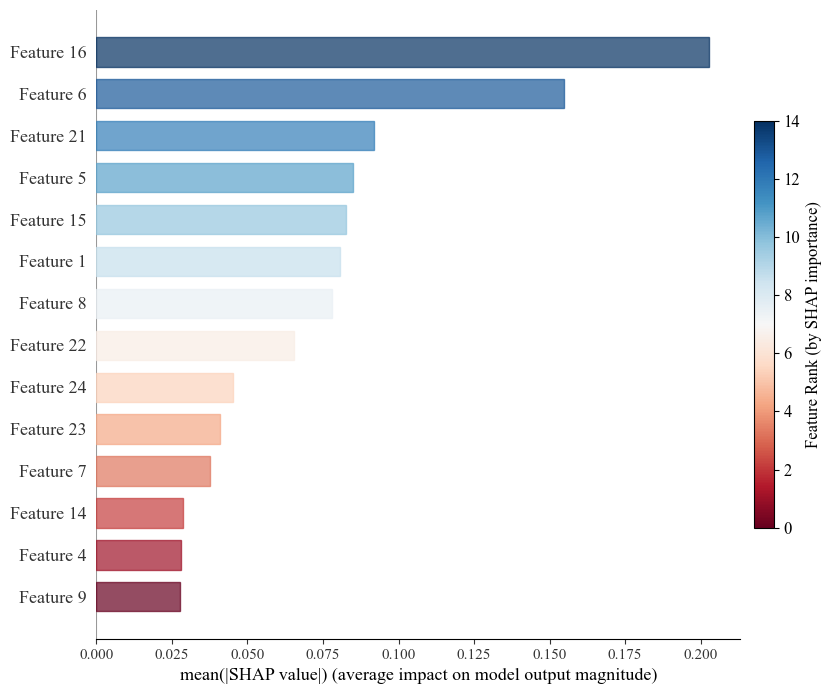

<positron-console-cell-8>:56: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.


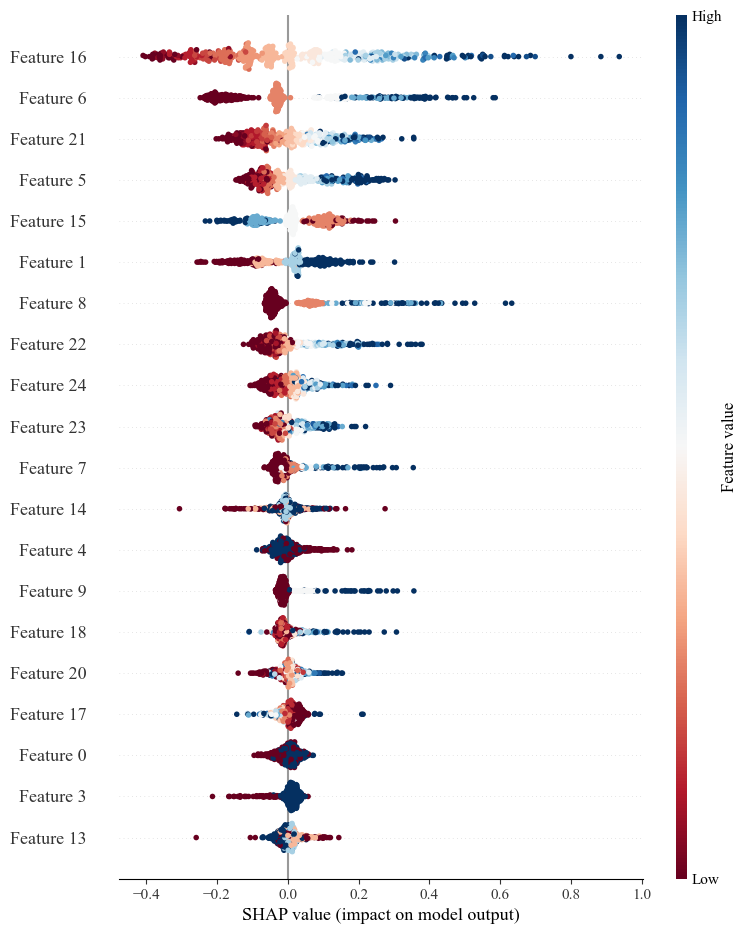

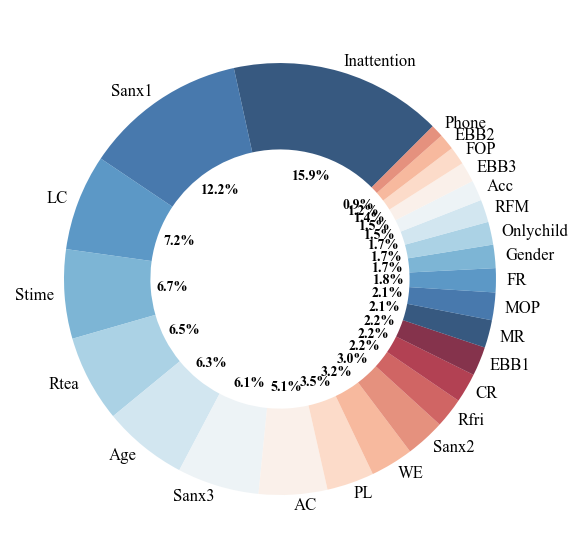

In [ ]:
# === SVR-only replacement added by 11_comment_svr_only_notebook.py ===
max_display = min(25, len(feature_cols))
top_indices = np.argsort(mean_shap_value1)[::-1][:max_display]

df_top = df_test_list_X.iloc[:, top_indices]
shap_values_top = shap_values[:, top_indices]

print("*******************************************************")

plt.figure()
plt.gcf().set_size_inches(5, 4)

plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = "Times New Roman"
plt.rcParams["font.size"] = 12

shap.summary_plot(
    shap_values_top,
    df_top,
    plot_type="bar",
    max_display=max_display,
    show=False,
)

ax = plt.gca()
cmap_name = "RdBu"
cmap = plt.get_cmap(cmap_name)
colors = cmap(np.linspace(0, 1, len(ax.patches)))

for bar, color in zip(ax.patches, colors):
    bar.set_color(color)
    bar.set_alpha(0.7)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=len(ax.patches)))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.7, aspect=20, fraction=0.03, pad=0.02)
cbar.set_label("Feature Rank (by SHAP importance)", fontsize=12)

plt.show()

plt.figure()
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = "Times New Roman"
plt.rcParams["font.size"] = 12

shap.summary_plot(
    shap_values_top,
    df_top,
    cmap=cmap_name,
    max_display=max_display,
    show=False,
)
plt.show()

labels = df_top.columns
sizes = mean_shap_value1[top_indices]
sizes_percent = sizes / mean_shap_value1.sum() * 100

fig, ax = plt.subplots(figsize=(6, 6))
colors_corrected = colors[::-1]

wedges, texts, autotexts = ax.pie(
    sizes,
    labels=labels,
    autopct="%1.1f%%",
    startangle=45,
    colors=colors_corrected,
    wedgeprops=dict(width=0.4, alpha=0.8),
    textprops={"fontsize": 10},
    pctdistance=0.5,
    labeldistance=1.05,
)

for autotext in autotexts:
    autotext.set_fontsize(10)
    autotext.set_weight("bold")

for text in texts:
    text.set_fontsize(12)

plt.tight_layout()
plt.show()



In [ ]:
# === SVR-only replacement added by 11_comment_svr_only_notebook.py ===
feature_importance_df = pd.DataFrame({
    "Feature": df_test_list_X.columns,
    "Mean_SHAP": mean_shap_value1,
})

feature_importance_sorted = feature_importance_df.sort_values(
    "Mean_SHAP", ascending=False
).reset_index(drop=True)
feature_importance_sorted["Rank"] = np.arange(1, len(feature_importance_sorted) + 1)

print("Top 25 features by mean |SHAP|:")
print(feature_importance_sorted.head(25).to_string(index=False))


各变量的平均|SHAP|值（Top 20）：
        Feature  Mean_SHAP  Rank
0   Inattention   0.202900    17
1         Sanx1   0.154809     7
2            LC   0.091806    22
3         Stime   0.084972     6
4          Rtea   0.082636    16
5           Age   0.080740     2
6         Sanx3   0.078071     9
7            AC   0.065271    23
8            PL   0.045074    25
9            WE   0.040930    24
10        Sanx2   0.037620     8
11         Rfri   0.028546    15
12           CR   0.028064     5
13         EBB1   0.027768    10
14           MR   0.026430    19
15          MOP   0.026332    21
16           FR   0.022925    18
17       Gender   0.022235     1
18    Onlychild   0.021827     4
19          RFM   0.021568    14


<positron-console-cell-10>:55: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


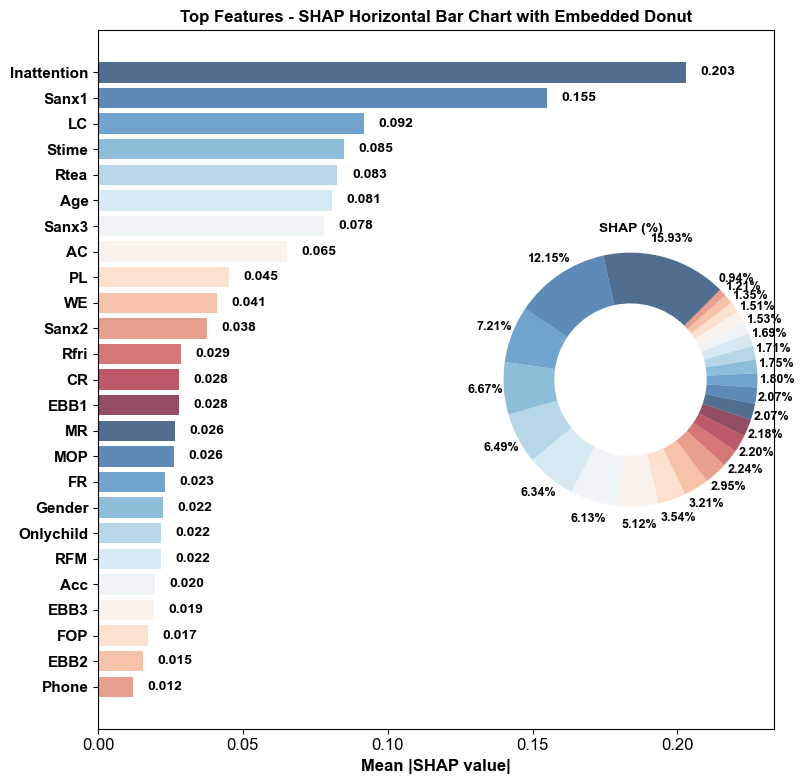

In [ ]:
# === SVR-only replacement added by 11_comment_svr_only_notebook.py ===
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.pyplot as plt
from matplotlib import rcParams

rcParams["pdf.fonttype"] = 42
rcParams["ps.fonttype"] = 42
rcParams["font.family"] = "sans-serif"
rcParams["font.sans-serif"] = ["Arial"]
rcParams["axes.unicode_minus"] = False

sizes_sel = sizes[:25]
labels_sel = labels[:25]
colors_sel = colors_corrected[:25]

fig, ax = plt.subplots(figsize=(8, 8))

bars = ax.barh(range(len(sizes_sel)), sizes_sel, color=colors_sel, alpha=0.7)
ax.set_yticks(range(len(labels_sel)))
ax.set_yticklabels(labels_sel, fontsize=11, fontweight="bold")
ax.set_xlabel("Mean |SHAP value|", fontsize=12, fontweight="bold")
ax.set_title("Top Features - SVR SHAP Horizontal Bar Chart with Embedded Donut", fontsize=12, fontweight="bold")

for bar, val in zip(bars, sizes_sel):
    width = bar.get_width()
    ax.text(
        width + 0.005,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.3f}",
        va="center",
        ha="left",
        fontsize=10,
        fontweight="bold",
    )

if len(sizes_sel) > 0:
    ax.set_xlim(0, max(sizes_sel) * 1.15)

ax_inset = inset_axes(ax, width="40%", height="40%", loc="center right")

wedges, texts, autotexts = ax_inset.pie(
    sizes_sel,
    labels=None,
    autopct="%1.2f%%",
    startangle=45,
    colors=colors_sel,
    wedgeprops=dict(width=0.4, alpha=0.7),
    textprops={"fontsize": 9},
    pctdistance=1.15,
)

for autotext in autotexts:
    autotext.set_fontsize(9)
    autotext.set_weight("bold")

ax_inset.set_title("SHAP (%)", fontsize=10, fontweight="bold")
ax_inset.axis("equal")
ax.invert_yaxis()

plt.tight_layout()
# plt.savefig("SHAP_chart3_RF.pdf", format="pdf", dpi=600, bbox_inches="tight")
plt.savefig("SHAP_chart3_SVR.pdf", format="pdf", dpi=600, bbox_inches="tight")
plt.show()

